In [1]:
from datasets import load_dataset
datasets = load_dataset("contemmcm/clinc150")
datasets

c:\projects\DecisionMaker\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    complete: Dataset({
        features: ['text', 'domain', 'intent', 'split'],
        num_rows: 23700
    })
})

In [2]:
import torch    
torch.cuda.is_available()

True

In [3]:
train_dataset = datasets.filter(lambda example: example["split"] == "train")
test_dataset = datasets.filter(lambda example: example["split"] == "test")

In [4]:
train_dataset = train_dataset.remove_columns("split")
test_dataset = test_dataset.remove_columns("split")

In [5]:
train_dataset = train_dataset["complete"]
test_dataset = test_dataset["complete"]

In [6]:
from datasets import DatasetDict
dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

In [7]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'domain', 'intent'],
        num_rows: 15000
    })
    test: Dataset({
        features: ['text', 'domain', 'intent'],
        num_rows: 4500
    })
})

In [8]:
dataset.set_format("pandas")
df = dataset["train"][:]
df

,text,domain,intent
0,what ingredients are in antipasto salad,3,34
1,is there enough money in my bank of hawaii for...,1,12
2,what's the nutrient info for a donut,3,36
3,tell me any events scheduled on my calendar fo...,4,55
4,check and confirm reservations at ruth chris f...,3,32
...,...,...,...
14995,does redrobin do reservations,3,45
14996,please call christy,7,97
14997,i gotta know who is your boss,9,123
14998,on my list of reminders is what,4,49


In [9]:
import numpy as np
import seaborn as sns

<Axes: xlabel='domain', ylabel='Count'>

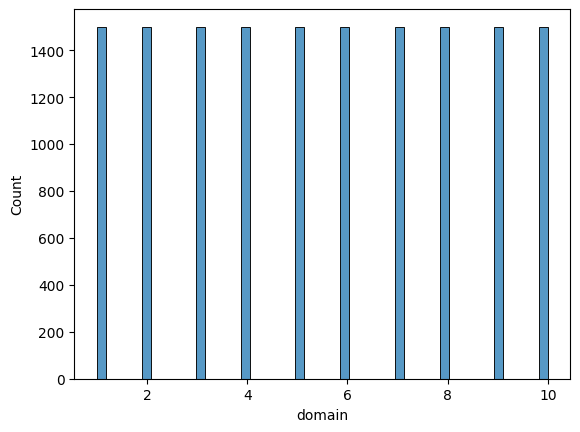

In [10]:
sns.histplot(df["domain"], bins=50)

In [11]:
lens = [len(text) for text in df["text"]]

In [12]:
np.min(lens)

np.int64(2)

In [13]:
dataset.reset_format()

In [14]:
from transformers import AutoTokenizer
model_ckpt = "bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [15]:
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

In [16]:
dataset = dataset.map(tokenize, batched=True)

In [17]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'domain', 'intent', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15000
    })
    test: Dataset({
        features: ['text', 'domain', 'intent', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4500
    })
})

In [18]:
dataset = dataset.rename_column(original_column_name="domain", new_column_name="label")

In [19]:
dataset["train"].features

{'text': Value('string'),
 'label': ClassLabel(names=['oos', 'banking', 'credit_cards', 'kitchen_and_dining', 'home', 'auto_and_commute', 'travel', 'utility', 'work', 'small_talk', 'meta']),
 'intent': ClassLabel(names=['oos:oos', 'banking:freeze_account', 'banking:routing', 'banking:pin_change', 'banking:bill_due', 'banking:pay_bill', 'banking:account_blocked', 'banking:interest_rate', 'banking:min_payment', 'banking:bill_balance', 'banking:transfer', 'banking:order_checks', 'banking:balance', 'banking:spending_history', 'banking:transactions', 'banking:report_fraud', 'credit_cards:replacement_card_duration', 'credit_cards:expiration_date', 'credit_cards:damaged_card', 'credit_cards:improve_credit_score', 'credit_cards:report_lost_card', 'credit_cards:card_declined', 'credit_cards:credit_limit_change', 'credit_cards:apr', 'credit_cards:redeem_rewards', 'credit_cards:credit_limit', 'credit_cards:rewards_balance', 'credit_cards:application_status', 'credit_cards:credit_score', 'credit_c

In [20]:
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
import torch

model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=11)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 827.30it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those para

In [21]:
model = model.to("cuda")

In [22]:
from peft import TaskType
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    target_modules=["query", "key", "value"],
    lora_alpha=8,

)
lora_model = get_peft_model(model, lora_config)


In [23]:
lora_model.print_trainable_parameters()

trainable params: 893,195 || all params: 109,211,926 || trainable%: 0.8179


In [24]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [25]:
import evaluate
import numpy as np
def compute_metrics(predictions):
    logits, labels = predictions
    accuracy = evaluate.load("accuracy")
    recall = evaluate.load("recall")
    precision = evaluate.load("precision")
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "recall": recall.compute(predictions=predictions, references=labels, average="macro", zero_division=0)["recall"],
        "precision": precision.compute(predictions=predictions, references=labels, average="macro", zero_division=0)["precision"]
    }


In [26]:
from transformers import TrainingArguments, Trainer
training_args = TrainingArguments(
    output_dir="../fine_tuning",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="steps",
    eval_steps=50,
    logging_strategy="steps",
    logging_steps=50,
    fp16=True,
    num_train_epochs=5
)

In [27]:
trainer = Trainer(
    args=training_args,
    model=lora_model,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [28]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,Recall,Precision
50,2.405168,2.340081,0.110889,0.110889,0.027715
100,2.352974,2.315286,0.105778,0.105778,0.055825
150,2.317395,2.304612,0.110889,0.110889,0.043746
200,2.328005,2.288510,0.125556,0.125556,0.121807
250,2.267124,2.283683,0.126222,0.126222,0.040407
300,2.301616,2.240692,0.190222,0.190222,0.130656
350,2.242332,2.151660,0.232667,0.232667,0.199588
400,2.140759,2.023815,0.261333,0.261333,0.278003
450,2.003198,1.923796,0.254889,0.254889,0.260775
500,1.928154,1.831024,0.267556,0.267556,0.274561


TrainOutput(global_step=9375, training_loss=0.9059307047526042, metrics={'train_runtime': 4437.734, 'train_samples_per_second': 16.901, 'train_steps_per_second': 2.113, 'total_flos': 694061542042560.0, 'train_loss': 0.9059307047526042, 'epoch': 5.0})

In [29]:
merged_model = lora_model.merge_and_unload()

In [33]:
from huggingface_hub import notebook_login
notebook_login()

In [35]:
merged_model.push_to_hub("ilia-dybal/domain-classifier")
tokenizer.push_to_hub("ilia-dybal/domain-classifier")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.07s/it]
Processing Files (1 / 1): 100%|██████████|  433MB /  433MB, 2.68MB/s  
New Data Upload: 100%|██████████|  185MB /  185MB, 2.68MB/s  
c:\projects\DecisionMaker\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dybal\.cache\huggingface\hub\models--ilia-dybal--domain-classifier. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.co

CommitInfo(commit_url='https://huggingface.co/ilia-dybal/domain-classifier/commit/bfc8ff73bec45850df4062f81b5b105af7c38fd6', commit_message='Upload tokenizer', commit_description='', oid='bfc8ff73bec45850df4062f81b5b105af7c38fd6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ilia-dybal/domain-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='ilia-dybal/domain-classifier'), pr_revision=None, pr_num=None)

In [36]:
from transformers import pipeline
classifier = pipeline("text-classification", model="ilia-dybal/domain-classifier")
classifier(dataset["test"]["text"][3])

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 687.15it/s, Materializing param=classifier.weight]                                      


[{'label': 'LABEL_7', 'score': 0.3792164623737335}]

In [37]:
label_names = dataset["train"].features["label"].names

In [38]:
label_names

['oos',
 'banking',
 'credit_cards',
 'kitchen_and_dining',
 'home',
 'auto_and_commute',
 'travel',
 'utility',
 'work',
 'small_talk',
 'meta']

In [39]:
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

In [40]:
merged_model.config.id2label = id2label
merged_model.config.label2id = label2id

In [41]:
merged_model.push_to_hub("ilia-dybal/domain-classifier")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.31it/s]
Processing Files (1 / 1): 100%|██████████|  433MB /  433MB,  179MB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


CommitInfo(commit_url='https://huggingface.co/ilia-dybal/domain-classifier/commit/00a9f01dcbfdf9393a1297c2fdaa039cb74d55ee', commit_message='Upload BertForSequenceClassification', commit_description='', oid='00a9f01dcbfdf9393a1297c2fdaa039cb74d55ee', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ilia-dybal/domain-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='ilia-dybal/domain-classifier'), pr_revision=None, pr_num=None)

In [42]:
classifier = pipeline("text-classification", model="ilia-dybal/domain-classifier")
text = dataset["test"]["text"][7]
classifier(text)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 685.40it/s, Materializing param=classifier.weight]                                      


[{'label': 'utility', 'score': 0.7569173574447632}]

In [45]:
text = dataset["test"]["text"][27]
text

'what are some interesting things i can do while in raleigh'

In [46]:
classifier(text)

[{'label': 'travel', 'score': 0.8490540981292725}]

In [49]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
model_ckpt = "ilia-dybal/domain-classifier"
tokenizer=AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 728.07it/s, Materializing param=classifier.weight]                                      


In [50]:
text = 'what are some interesting things i can do while in raleigh'

In [51]:
tokenized_text = tokenizer(text, return_tensors="pt").to("cuda")
tokenized_text

{'input_ids': tensor([[  101,  1184,  1132,  1199,  5426,  1614,   178,  1169,  1202,  1229,
          1107,   187,  7531, 21523,   102]], device='cuda:0'), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}

In [52]:
model.to("cuda")

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [53]:
with torch.no_grad():
    outputs = model(**tokenized_text)
    predicted_id = outputs.logits.argmax(-1).item()
label = id2label[predicted_id]
label

'travel'

In [54]:
predicted_id

6